In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(6839120, 2)
(6839120, 4)


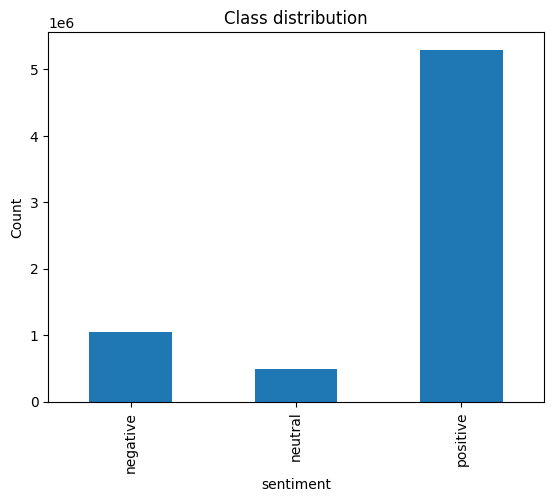

,proportion
sentiment,
positive,0.774308
negative,0.152960
neutral,0.072732


In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders=sorted(base_path.glob("year=*"))

dfs=[]
for year_folder in year_folders:
  parquet_files=sorted(year_folder.glob("*.parquet"))
  for parquet_file in parquet_files:
    df=pd.read_parquet(parquet_file, columns=['parent_asin', 'rating', 'review_title', 'review'])
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    df = df[df['rating'].between(1, 5)]
    df = df.dropna(subset=['rating'])
    df['review_title'] = df['review_title'].fillna("").astype(str)
    df['review']=df['review'].fillna("").astype(str)
    df['total_review'] = (df['review_title'].str.strip() + " " + df['review'].str.strip()).str.strip()
    df = df[df['total_review'].str.len()>0]
    dfs.append(df[['rating', 'total_review']])

reviews=pd.concat(dfs, ignore_index=True)
print(reviews.shape)
reviews.head()

reviews["sentiment"] = np.select([reviews["rating"] <=2.5 ,(reviews["rating"] >= 2.5) & (reviews["rating"] <= 3.5),reviews["rating"] > 3.5],["negative", "neutral", "positive"],default="unknown")
reviews["label"]=np.select([reviews["rating"] <=2.5 ,(reviews["rating"] >= 2.5) & (reviews["rating"] <= 3.5),reviews["rating"] > 3.5],["0", "1", "2"],default="unknown")
print(reviews.shape)
reviews.head()
reviews["sentiment"].value_counts().sort_index().plot(kind="bar")
plt.title("Class distribution")
plt.ylabel("Count")
plt.show()
# % of how many rating exist in each segment
reviews["sentiment"].value_counts(normalize=True)

In [ ]:
#use the saved model for predictions
from transformers import pipeline
save_path="/content/drive/MyDrive/Jewelry_Project/Data_Science/Sentiment_models/Sentiment_models_distilbert-base-uncased/"
classifier = pipeline("text-classification",model=save_path,tokenizer=save_path)

texts = [
    "Beautiful necklace, great quality and arrived quickly.",
    "The ring is okay, nothing special.",
    "Terrible product, broke after one day."
]

preds = classifier(texts)
preds

Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

[{'label': 'positive', 'score': 0.9997161030769348},
 {'label': 'neutral', 'score': 0.7780870795249939},
 {'label': 'negative', 'score': 0.9987831711769104}]

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

save_path = "/content/drive/MyDrive/Jewelry_Project/Data_Science/Sentiment_models/Sentiment_models_distilbert-base-uncased/"

tokenizer = AutoTokenizer.from_pretrained(save_path)
model = AutoModelForSequenceClassification.from_pretrained(save_path)

model.eval()

texts = [
    "Beautiful necklace, great quality and arrived quickly.",
    "The ring is okay, nothing special.",
    "Terrible product, broke after one day."
]

inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
y_prob = F.softmax(logits, dim=1)
y_pred = torch.argmax(y_prob, dim=1)

print("Logits:", logits)
print("Probabilities (y_prob):", y_prob)
print("Predicted classes:", y_pred)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Logits: tensor([[-5.4084, -4.9287,  3.7199],
        [-1.3590,  0.6461, -1.2473],
        [ 2.5747, -4.9619, -4.7113]])
Probabilities (y_prob): tensor([[1.0852e-04, 1.7532e-04, 9.9972e-01],
        [1.0477e-01, 7.7809e-01, 1.1714e-01],
        [9.9878e-01, 5.3254e-04, 6.8421e-04]])
Predicted classes: tensor([2, 1, 0])


In [ ]:
import re
import ast
import pandas as pd
import matplotlib.pyplot as plt

log_path = "/content/drive/MyDrive/Jewelry_Project/Data_Science/Sentiment_models/Sentiment_models_distilbert-base-uncased/sentiment_model_distilbert-base-uncased.out"   # change if needed

with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

matches = re.findall(r"\{[^\n]*'epoch':\s*[0-9.]+[^\n]*\}", text)

records = []
for m in matches:
    try:
        d = ast.literal_eval(m)
        records.append(d)
    except Exception:
        pass

history_df = pd.DataFrame(records)
history_df

,loss,grad_norm,learning_rate,epoch,eval_loss,eval_accuracy,eval_f1_macro,eval_precision_macro,eval_recall_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,train_loss
0,0.1993,2.322097,0.000013,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,0.191279,0.928323,0.782207,0.805299,0.772456,650.3132,1051.666,65.730,NaN,NaN,NaN,NaN
2,0.1838,1.974066,0.000007,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,0.190745,0.929152,0.792408,0.801965,0.787538,650.0380,1052.111,65.758,NaN,NaN,NaN,NaN
4,0.1714,1.884976,0.000000,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,0.196981,0.929098,0.794102,0.802231,0.788616,649.3629,1053.205,65.826,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50826.8275,322.937,20.184,0.184833
7,NaN,NaN,NaN,3.0,0.197126,0.929282,0.795370,0.803325,0.789932,649.2889,1053.325,65.834,NaN,NaN,NaN,NaN


In [7]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
from sklearn.metrics import f1_score, precision_score, recall_score

df = pd.read_csv("/content/drive/MyDrive/Jewelry_Project/Data_Science/Sentiment_models/Sentiment_models_distilbert-base-uncased/test_predictions.csv")
# df
y_true=df['y_true'].to_numpy()
y_pred=df['y_pred'].to_numpy()
class_labels= ['negative', 'neutral','positive']
acc= accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")
f1_macro = f1_score(y_true, y_pred, average="macro")
print("Test macro F1:", f1_macro)
f1_weighted = f1_score(y_true, y_pred, average="weighted")
print("Test weighted F1:", f1_weighted)
precision_macro = precision_score(y_true, y_pred, average="macro")
print("Test macro precision:", precision_macro)
recall_macro = recall_score(y_true, y_pred, average="macro")
print("Test macro recall:", recall_macro)
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4,output_dict=True))


Accuracy: 0.9293
Test macro F1: 0.7953702409851151
Test weighted F1: 0.9273767848051226
Test macro precision: 0.8033253064303478
Test macro recall: 0.7899322312952641
{'negative': {'precision': 0.8509782092929883, 'recall': 0.8914645687356014, 'f1-score': 0.8707510305837095, 'support': 104611.0}, 'neutral': {'precision': 0.5861201851895372, 'recall': 0.501387157733907, 'f1-score': 0.5404526887196212, 'support': 49742.0}, 'positive': {'precision': 0.972877524808518, 'recall': 0.9769449674162841, 'f1-score': 0.9749070036520147, 'support': 529559.0}, 'accuracy': 0.9292818374293769, 'macro avg': {'precision': 0.8033253064303478, 'recall': 0.7899322312952641, 'f1-score': 0.7953702409851151, 'support': 683912.0}, 'weighted avg': {'precision': 0.9261023653103333, 'recall': 0.9292818374293769, 'f1-score': 0.9273767848051226, 'support': 683912.0}}


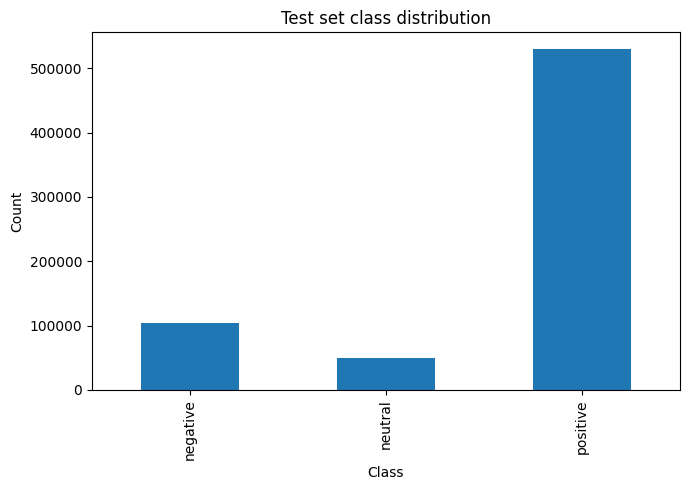

In [ ]:
true_counts = pd.Series(y_true).value_counts().sort_index()
true_counts.index = class_labels

plt.figure(figsize=(7, 5))
true_counts.plot(kind="bar")
plt.title("Test set class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred) #, average='weighted'
# df_metrix = pd.DataFrame({
#     'Class': class_labels,
#     'Precision': precision,
#     'Recall': recall,
#     'F1-Score': f1,
#     'Support': support})
# print(df_metrix)

# x = np.arange(len(class_labels))
# width = 0.25
# plt.figure(figsize=(9, 6))
# plt.bar(x - width, precision, width, label="Precision")
# plt.bar(x, recall, width, label="Recall")
# plt.bar(x + width, f1, width, label="F1-score")
# plt.xticks(x, class_labels)
# plt.ylim(0, 1.05)
# plt.ylabel("Score")
# plt.title("Perclass evaluation metrics")
# plt.legend()
# plt.tight_layout()
# plt.show()

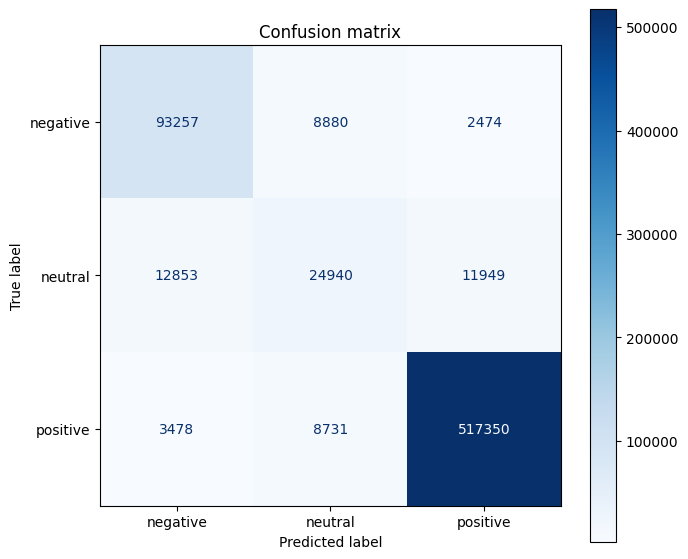

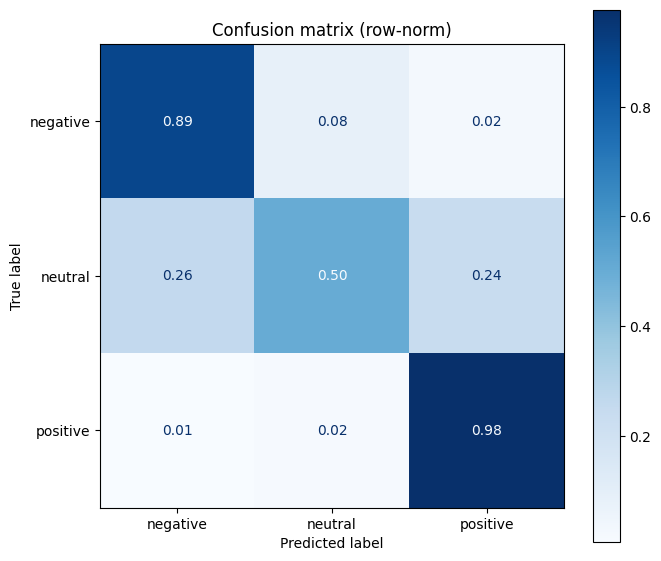

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm=confusion_matrix(y_true, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f")
plt.title("Confusion matrix (row-norm)")
plt.tight_layout()
plt.show()


In [2]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import test
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders=sorted(base_path.glob("year=*"))

dfs=[]
for year_folder in year_folders:
    parquet_files=sorted(year_folder.glob("*.parquet"))
    for parquet_file in parquet_files:
        df=pd.read_parquet(parquet_file, columns=['parent_asin', 'rating', 'review_title', 'review'])
        df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
        df = df[df['rating'].between(1, 5)]
        df = df.dropna(subset=['rating'])
        df['review_title'] = df['review_title'].fillna("").astype(str)
        df['review']=df['review'].fillna("").astype(str)
        df['total_review'] = (df['review_title'].str.strip() + " " + df['review'].str.strip()).str.strip()
        df = df[df['total_review'].str.len()>0]
        dfs.append(df[['rating', 'total_review']])

reviews=pd.concat(dfs, ignore_index=True)
print(reviews.shape)
reviews.head()

reviews["sentiment"] = np.select([reviews["rating"] <=2.5 ,(reviews["rating"] >= 2.5) & (reviews["rating"] <= 3.5),reviews["rating"] > 3.5],["negative", "neutral", "positive"],default="unknown")
reviews["label"]=np.select([reviews["rating"] <=2.5 ,(reviews["rating"] >= 2.5) & (reviews["rating"] <= 3.5),reviews["rating"] > 3.5],["0", "1", "2"],default="unknown")
print(reviews.shape)

train_df, testval_df = train_test_split(reviews, test_size=0.2, stratify=reviews['label'], random_state=42)
test_df, val_df = train_test_split(testval_df, test_size=0.5, stratify=testval_df['label'], random_state=42)
print("train shape:", train_df.shape)
print("val shape:", val_df.shape)
print("test shape:", test_df.shape)
train_df["label"] = train_df["label"].astype(int)
val_df["label"] = val_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)


save_path = "/content/drive/MyDrive/Jewelry_Project/Data_Science/Sentiment_models/Sentiment_models_distilbert-base-uncased/"

tokenizer = AutoTokenizer.from_pretrained(save_path)
model = AutoModelForSequenceClassification.from_pretrained(save_path)
model.to(device)
model.eval()

texts = test_df['total_review'].tolist()
y_true = test_df['label'].to_numpy()

batch_size = 32
all_probs = []
all_preds = []
with torch.no_grad():
  for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
    logits = outputs.logits
    probs = F.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    all_probs.append(probs.cpu().numpy())
    all_preds.append(preds.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)


True
(6839120, 2)
(6839120, 4)
train shape: (5471296, 4)
val shape: (683912, 4)
test shape: (683912, 4)


Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

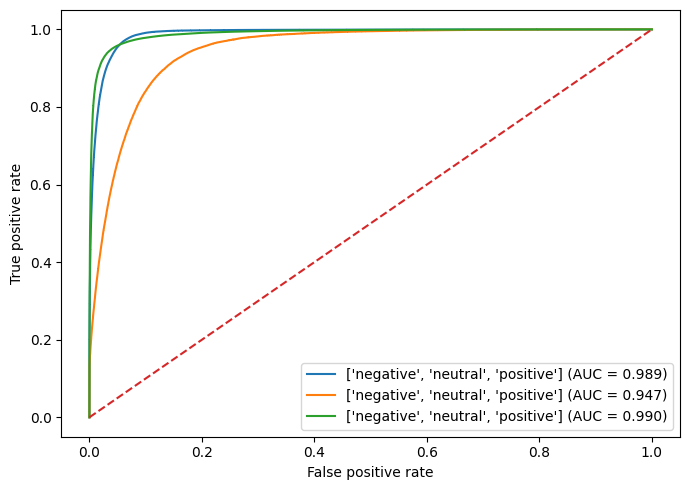

In [8]:
#multi-class ROC analysis
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
if all_probs.shape[0] == len(class_labels) and all_probs.shape[1] == len(y_true):
    all_probs = all_probs.T

plt.figure(figsize=(7, 5))
for i, class_name in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.show()

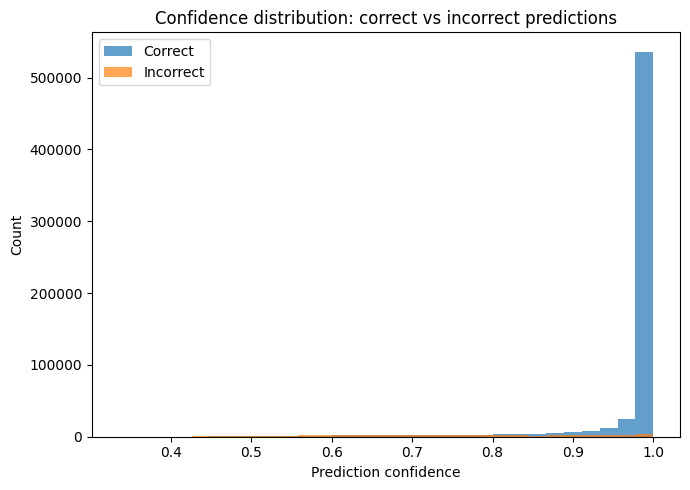

In [10]:
#to see if wrong predictions are often high confidence, calibration needs work.
confidence = all_probs.max(axis=1)
correct = (y_pred == y_true)

conf_df = pd.DataFrame({
    "confidence": confidence,
    "correct": correct})

plt.figure(figsize=(7, 5))
plt.hist(conf_df.loc[conf_df["correct"], "confidence"], bins=30, alpha=0.7, label="Correct")
plt.hist(conf_df.loc[~conf_df["correct"], "confidence"], bins=30, alpha=0.7, label="Incorrect")
plt.xlabel("Prediction confidence")
plt.ylabel("Count")
plt.title("Confidence distribution: correct vs incorrect predictions")
plt.legend()
plt.tight_layout()
plt.show()